In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


### Step 1: Initial Setup and Data Access

First, we establish our environment and access our data resources. This involves mounting Google Drive to access stored files and importing necessary libraries for our machine learning task.

#### Cell `ONKvJhTibOag`: Mounting Google Drive

```python
from google.colab import drive
drive.mount('/content/drive')
```

**Explanation:** This cell is crucial for persistent storage and accessing our dataset. By mounting Google Drive, we ensure that our model checkpoints and raw data can be read from and written to a location that persists across Colab sessions. This is a standard practice in Colab for managing project assets.

**Output:** `Mounted at /content/drive` indicates successful integration with Google Drive.

#### Cell `L7sofejzbXmb`: Importing Essential Libraries

```python
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score

import numpy as np
import matplotlib.pyplot as plt

import cv2
from PIL import Image
import json
```

**Explanation:** This block imports all the Python libraries required for our project. We're primarily working with PyTorch (`torch`, `torch.nn`, `torch.optim`), torchvision (`datasets`, `transforms`, `models`) for computer vision tasks and pre-trained models, and `torch.utils.data.DataLoader` for efficient data loading. `sklearn.metrics` is included for evaluating model performance, `numpy` for numerical operations, `matplotlib.pyplot` for plotting, `cv2` and `PIL.Image` for image processing, and `json` for saving and loading metrics.

**Output:** No explicit output, as this cell only imports libraries. Success is indicated by the absence of errors.

### Step 2: Data Preprocessing and Face Masking

Before training, the raw image data needs to be processed. This involves a critical step of masking faces to ensure the model focuses on general expressions rather than facial identity, followed by resizing and normalization.

#### Cell `Nu8gIHZwKPWM`: Installing MediaPipe

```python
!pip install mediapipe
```

**Explanation:** MediaPipe is a cross-platform framework for building multimodal applied machine learning pipelines. We install it here because it provides a highly efficient and accurate face detection solution, which we'll use to mask faces in our dataset. This step ensures that the necessary library is available in our Colab environment.

**Output:** The output shows the successful installation of `mediapipe` and its dependencies, including version details and confirmation that `absl-py` was updated.

#### Cell `dUD98adtpeed`: Downloading MediaPipe Face Detection Model

```python
!mkdir -p /tmp/mediapipe_models
!wget -nc https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite \
  -O /tmp/mediapipe_models/blaze_face_short_range.tflite
```

**Explanation:** This cell downloads a pre-trained `blaze_face_short_range.tflite` model from Google's MediaPipe models repository. This model is specifically designed for efficient face detection. We store it in a temporary directory `/tmp/mediapipe_models`. The `-nc` flag with `wget` ensures that the file is only downloaded if it doesn't already exist, preventing unnecessary re-downloads.

**Output:** `File ‘/tmp/mediapipe_models/blaze_face_short_range.tflite’ already there; not retrieving.` indicates the model was already downloaded in a previous run, or it has been successfully downloaded.

#### Cell `YZjbvovy4e77`: Face Masking Function and Execution

```python
import os
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

face_detector_model_path = '/tmp/mediapipe_models/blaze_face_short_range.tflite'

base_options = python.BaseOptions(model_asset_path=face_detector_model_path)

options = vision.FaceDetectorOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    min_detection_confidence=0.5
)

detector = vision.FaceDetector.create_from_options(options)

def mask_faces_in_folder(input_root, output_root):
    os.makedirs(output_root, exist_ok=True)

    for root, _, files in os.walk(input_root):
        rel = os.path.relpath(root, input_root)
        save_dir = os.path.join(output_root, rel)
        os.makedirs(save_dir, exist_ok=True)

        for f in files:
            if not f.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            img_path = os.path.join(root, f)
            image = cv2.imread(img_path)
            if image is None:
                continue

            h, w, _ = image.shape

            mp_image = mp.Image(
                image_format=mp.ImageFormat.SRGB,
                data=cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            )

            result = detector.detect(mp_image)

            if result.detections:
                for det in result.detections:
                    bbox = det.bounding_box
                    x1 = max(0, bbox.origin_x)
                    y1 = max(0, bbox.origin_y)
                    x2 = min(w, x1 + bbox.width)
                    y2 = min(h, y1 + bbox.height)

                    # Mask face
                    image[y1:y2, x1:x2] = 0

            cv2.imwrite(os.path.join(save_dir, f), image)

train_input_folder = "/content/drive/MyDrive/CAER-S/train"
test_input_folder = "/content/drive/MyDrive/CAER-S/test"

train_output_folder = "/content/ssd_masked/train"
test_output_folder = "/content/ssd_masked/test"

mask_faces_in_folder(train_input_folder, train_output_folder)
mask_faces_in_folder(test_input_folder, test_output_folder)
```

**Explanation:** This is a core preprocessing step. We initialize the MediaPipe `FaceDetector` using the downloaded model. The `mask_faces_in_folder` function iterates through all images in specified input directories (training and testing sets of the CAER-S dataset from Google Drive). For each image, it performs face detection. If a face is detected, the bounding box coordinates are used to black out the facial region in the image using `cv2.imwrite`. This creates a new dataset where faces are masked, which is saved to `/content/ssd_masked/train` and `/content/ssd_masked/test`. The goal is to encourage the emotion recognition model to learn from contextual cues and body language rather than potentially biased facial features.

**Output:** No explicit output from the function call, but success is implied by the creation of the masked image directories. Any errors during processing would be reported here.

#### Cell `PDSUplamrfyo`: Verifying Model Path

```python
MODEL_PATH = "/tmp/mediapipe_models/blaze_face_short_range.tflite"
print("Model exists:", os.path.exists(MODEL_PATH))
```

**Explanation:** This cell simply verifies that the MediaPipe face detection model file, which was supposed to be downloaded or already exist, is indeed present at the specified path. This is a sanity check before attempting to use the model.

**Output:** `Model exists: True` indicates the model file is accessible, confirming the previous download step was successful.

#### Cell `sBi8gxuQrTbu`: Preprocessing and Saving Images Function

```python
import os

# Paths
src_train = "/content/ssd_masked/train"   # original dataset
src_test  = "/content/ssd_masked/test"
dst_train = "/content/CAERS-ssd/train"             # preprocessed dataset on SSD
dst_test  = "/content/CAERS-ssd/test"

# Image size
IMG_SIZE = 224

# Function to preprocess and save images

def preprocess_and_save(src_folder, dst_folder):
    for emotion in os.listdir(src_folder):
        src_emotion_dir = os.path.join(src_folder, emotion)

        if not os.path.isdir(src_emotion_dir):
            continue

        dst_emotion_dir = os.path.join(dst_folder, emotion)
        os.makedirs(dst_emotion_dir, exist_ok=True)

        for fname in os.listdir(src_emotion_dir):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            src_path = os.path.join(src_emotion_dir, fname)
            dst_path = os.path.join(dst_emotion_dir, fname)

            img = Image.open(src_path).convert("RGB")
            img = img.resize((IMG_SIZE, IMG_SIZE))
            img.save(dst_path)
```

**Explanation:** This cell defines the `preprocess_and_save` function. This function takes a source folder (containing the masked images) and a destination folder. It iterates through each emotion category, reads each image, converts it to RGB format (ensuring consistency), resizes it to `IMG_SIZE` (224x224 pixels, a common input size for many pre-trained CNNs like ResNet), and saves the processed image to the destination folder. This step standardizes the image dimensions for model input.

**Output:** No explicit output, as this cell only defines the function.

#### Cell `_LvWzwMmrZN1`: Executing Image Preprocessing

```python
preprocess_and_save(src_train, dst_train)
preprocess_and_save(src_test, dst_test)
```

**Explanation:** Here, we invoke the `preprocess_and_save` function for both our training and testing datasets. The masked images from `/content/ssd_masked/train` and `/content/ssd_masked/test` are resized to 224x224 pixels and saved into `/content/CAERS-ssd/train` and `/content/CAERS-ssd/test` respectively. This is the final step in preparing the image files before they are loaded into PyTorch DataLoaders.

**Output:** No explicit output, but indicates successful processing and saving of all images. This can be time-consuming depending on dataset size.

#### Cell `rk_u56-oH_Mv`: Listing Content Directory

```python
!ls /content/
```

**Explanation:** This shell command lists the contents of the `/content/` directory. This is useful for verifying that our new `CAERS-ssd` directory (containing the preprocessed, masked images) has been successfully created and populated.

**Output:** `CAERS-ssd CAERS-ssd- drive resnet_metrics.json sample_data ssd_masked` confirms the presence of `CAERS-ssd` and `ssd_masked` directories, along with other files/folders.

#### Cell `9dfa43b3`: Displaying a Random Masked Image

```python
import matplotlib.pyplot as plt
import random
import os
import cv2

def display_random_masked_image(output_folder):
    all_masked_images = []
    for root, _, files in os.walk(output_folder):
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_masked_images.append(os.path.join(root, f))

    if not all_masked_images:
        print(f"No masked images found in {output_folder}")
        return

    random_image_path = random.choice(all_masked_images)
    print(f"Displaying: {random_image_path}")
    img = cv2.imread(random_image_path)
    if img is not None:
        # OpenCV reads images in BGR, matplotlib expects RGB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
        plt.title("Sample Masked Image")
        plt.axis('off')
        plt.show()
    else:
        print(f"Could not load image: {random_image_path}")

display_random_masked_image(train_output_folder)
```

**Explanation:** This utility function is designed to visually inspect the results of the face masking. It randomly selects an image from the `train_output_folder` (which contains the masked images) and displays it using `matplotlib`. This provides a quick visual confirmation that the face masking process worked as intended.

**Output:** `No masked images found in /content/ssd_masked/train` suggests that `train_output_folder` was not correctly set or the `mask_faces_in_folder` function did not populate this directory as expected. This indicates a potential issue or misconfiguration in how the masking output was handled or where the display function was looking.

### Step 3: Data Loading and Transformation for Training

With images preprocessed, we now define the data transformations and set up PyTorch DataLoaders to efficiently feed data to our model during training and evaluation.

#### Cell `KgLrJKrAgFAO`: Defining Image Transformations and Batch Size

```python
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
```

**Explanation:** We define `BATCH_SIZE` as 32, a common choice for GPU memory efficiency and training stability. The `train_transforms` and `test_transforms` pipelines are defined using `torchvision.transforms.Compose`. Both consist of two main steps:
1. `transforms.ToTensor()`: Converts PIL images to PyTorch tensors and scales pixel values from [0, 255] to [0.0, 1.0].
2. `transforms.Normalize()`: Normalizes the tensor image with a mean and standard deviation. These specific values are standard for images pre-trained on ImageNet, which is typically used for transfer learning with models like ResNet. This step is crucial for matching the input distribution of the pre-trained model and improving training efficiency.

**Output:** No output, as this cell only defines variables and transformations.

#### Cell `QPuY1VPYbfr7`: Creating Datasets and DataLoaders

```python
train_dir = "/content/CAERS-ssd/train"
test_dir = "/content/CAERS-ssd/test"

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,        # IMPORTANT
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
```

**Explanation:** This cell sets up our data pipelines. `datasets.ImageFolder` is used to load images from the preprocessed directories, automatically inferring class labels from subfolder names. The previously defined `train_transforms` and `test_transforms` are applied during loading.

`DataLoader` objects are then created for both training and testing datasets. These loaders provide iterable access to the data in mini-batches. `shuffle=True` is used for the training loader to randomize data order in each epoch, aiding generalization. `num_workers=0` (which is often `2` or `4` in general, but `0` here means the main process will load the data) and `pin_memory=True` are set for optimal performance on GPU. Finally, `class_names` and `num_classes` are extracted, which are essential for configuring the model's output layer.

**Output:** `Classes: ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']` confirms that the dataset was correctly loaded and the class names (emotions) were extracted as expected.

### Step 4: Model Definition and Initialization

We now define our deep learning model, utilizing transfer learning from a pre-trained ResNet architecture.

#### Cell `era5f6Gpbh2y`: Model Setup (ResNet18)

```python
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)

# Replace final classification layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)
```

**Explanation:** This cell initializes our model. First, it determines the `device` to use for computation (GPU if available, otherwise CPU) for optimal training speed. We then load a `resnet18` model, pre-trained on the ImageNet dataset (`pretrained=True`). This is a powerful technique called transfer learning, where the model has already learned rich feature representations from a large dataset, and we fine-tune it for our specific task.

The critical modification is replacing the final fully connected layer (`model.fc`). The original `resnet18` was trained for 1000 classes (ImageNet), but our task has `num_classes` (7 emotions). We replace `model.fc` with a new `nn.Linear` layer that takes the same input features but outputs `num_classes`. Finally, the model is moved to the selected `device`.

**Output:** The output shows `Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth"...` if the pre-trained weights are not cached, followed by a progress bar. Warnings about `pretrained` deprecation are standard but do not indicate an error. The final line `100%|██████████| 44.7M/44.7M [00:00<00:00, 88.1MB/s]` confirms successful download of weights.

#### Cell `KG_nbDbLRAm2`: Loss Function and Optimizer

```python
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
```

**Explanation:** Here, we define the `criterion` (loss function) and the `optimizer` for training:
- `nn.CrossEntropyLoss()`: This is a standard loss function for multi-class classification problems, especially when the output of the model is raw logits (not probabilities yet). It combines `LogSoftmax` and `NLLLoss` in one single class.
- `optim.Adam(model.parameters(), lr=1e-4)`: The Adam optimizer is chosen for its efficiency and good performance in practice. It adapts the learning rate for each parameter. We initialize it with a learning rate (`lr`) of 0.0001 (1e-4).

**Output:** No output, as this cell only initializes variables.

### Step 5: Model Training and Evaluation Loop

This is the core training phase, where the model learns from the data. We iterate through epochs, performing forward and backward passes, updating weights, and evaluating performance on a validation set.

#### Cell `8ILop3clbkLD`: Training and Validation Loop

```python
EPOCHS = 10

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
val_precisions = []
val_recalls = []
val_f1s = []

metrics_file = "/content/resnet_metrics.json"

print("Entering training loop")

for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1} started")

    # ----------------- Training -----------------
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, (images, labels) in enumerate(train_loader):
        if i % 100 == 0:
            print(f"  Training batch {i}/{len(train_loader)}")

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    train_acc = correct_train / total_train
    train_accuracies.append(train_acc)

    # ----------------- Validation -----------------
    model.eval()
    running_val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for i, (images, labels) in enumerate(test_loader):
            if i % 100 == 0:
                print(f"  Eval batch {i}/{len(test_loader)}")

            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = running_val_loss / len(test_loader)
    val_losses.append(avg_val_loss)

    acc = (torch.tensor(all_preds) == torch.tensor(all_labels)).float().mean().item()
    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    val_accuracies.append(acc)
    val_precisions.append(precision)
    val_recalls.append(recall)
    val_f1s.append(f1)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] - "
        f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}, "
        f"Val Loss: {avg_val_loss:.4f}, Val Acc: {acc:.4f}, "
        f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}"
    )

    # ----------------- Save metrics to JSON -----------------
    epoch_metrics = {
        "epoch": epoch + 1,
        "train_loss": avg_train_loss,
        "train_accuracy": train_acc,
        "val_loss": avg_val_loss,
        "val_accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }

    try:
        with open(metrics_file, "r") as f:
            all_metrics = json.load(f)
    except FileNotFoundError:
        all_metrics = []

    all_metrics.append(epoch_metrics)

    with open(metrics_file, "w") as f:
        json.dump(all_metrics, f, indent=4)

    # Save model checkpoint
    torch.save(model.state_dict(), "/content/drive/MyDrive/resnet18_emotion_model.pth")
```

**Explanation:** This is the heart of the training process, executed for `EPOCHS = 10` iterations. Each epoch consists of two phases:

1.  **Training Phase (`model.train()`):**
    *   The model is set to training mode, enabling dropout layers and batch normalization updates.
    *   It iterates through `train_loader`, processing images in batches.
    *   For each batch, `optimizer.zero_grad()` clears previous gradients.
    *   `outputs = model(images)` performs a forward pass.
    *   `loss = criterion(outputs, labels)` calculates the loss.
    *   `loss.backward()` computes gradients.
    *   `optimizer.step()` updates model weights.
    *   Training loss and accuracy are calculated and accumulated.

2.  **Validation Phase (`model.eval()`):**
    *   The model is set to evaluation mode, disabling dropout and freezing batch normalization layers.
    *   `torch.no_grad()` is used to prevent gradient computation, saving memory and speeding up evaluation.
    *   It iterates through `test_loader` to evaluate the model on unseen data.
    *   Validation loss, accuracy, precision, recall, and F1-score are calculated. Precision, recall, and F1-score are especially important for multi-class classification to understand performance beyond simple accuracy, especially with imbalanced datasets. We use `average="macro"` for these metrics, giving equal weight to each class.

**Metrics Saving and Model Checkpointing:**
    *   After each epoch, all calculated metrics (train loss/accuracy, validation loss/accuracy, precision, recall, F1-score) are stored in a JSON file (`/content/resnet_metrics.json`). This allows for later analysis and plotting of training progress.
    *   The model's state dictionary (`model.state_dict()`) is saved to Google Drive (`/content/drive/MyDrive/resnet18_emotion_model.pth`) after each epoch. This ensures that we always have the latest trained model available, even if the Colab session disconnects.

**Output:** The output displays detailed progress for each epoch, including training batch status, training/validation loss and accuracy, and the calculated precision, recall, and F1-score for the validation set. This allows us to monitor the model's learning trajectory and performance. We can observe the model's performance improving over the epochs, with training accuracy reaching `0.9806` and validation accuracy reaching `0.8652` by the final epoch.

### Step 6: Visualization of Training Metrics

After training, we visualize the collected metrics to understand the model's learning behavior and performance trends over epochs.

#### Cell `Pg2qKYb9bmx9`: Plotting Training Metrics

```python
import json
import matplotlib.pyplot as plt

# Load metrics
metrics_file = "/content/resnet_metrics.json"
with open(metrics_file, "r") as f:
    metrics = json.load(f)

# Extract metrics
epochs = [m['epoch'] for m in metrics]
train_losses = [m['train_loss'] for m in metrics]
val_losses = [m['val_loss'] for m in metrics]
train_accs = [m.get('train_accuracy', None) for m in metrics]
val_accs = [m['val_accuracy'] for m in metrics]
val_f1s = [m['f1_score'] for m in metrics]

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, label="Train Loss", marker='o')
plt.plot(epochs, val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

# Plot Accuracy
plt.figure(figsize=(10, 5))
if all(train_accs):
    plt.plot(epochs, train_accs, label="Train Accuracy", marker='o')
plt.plot(epochs, val_accs, label="Validation Accuracy", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

# Plot F1-Score
plt.figure(figsize=(10, 5))
plt.plot(epochs, val_f1s, label="Validation F1-Score", marker='o', color='purple')
plt.xlabel("Epoch")
plt.ylabel("F1-Score")
plt.title("Validation F1-Score vs Epoch")
plt.legend()
plt.grid(True)
plt.show()
```

**Explanation:** This cell loads the saved training metrics from `/content/resnet_metrics.json` and visualizes them using `matplotlib.pyplot`. Three separate plots are generated:
1.  **Loss vs. Epoch:** Shows both training and validation loss over time. This helps identify overfitting (validation loss increasing while training loss decreases) or underfitting.
2.  **Accuracy vs. Epoch:** Displays training and validation accuracy. Similar to loss, this helps assess how well the model is generalizing.
3.  **Validation F1-Score vs. Epoch:** Plots the macro-averaged F1-score on the validation set. F1-score is a harmonic mean of precision and recall, providing a balanced measure of a model's accuracy, especially relevant for classification problems.

These plots are crucial for understanding the model's performance, identifying trends, and deciding if further training or hyperparameter tuning is needed.

**Output:** Three distinct plots will be displayed, visualizing the training and validation loss, accuracy, and validation F1-score over the 10 epochs. These plots provide a clear visual summary of the training progress.

### Step 7: Post-Training Cleanup and Model Loading for Inference

After training and analysis, we perform some cleanup and prepare the trained model for making predictions on new images.

#### Cell `o56hKheYwGat`: Copying CAER-S Dataset

```python
!cp -r /content/drive/MyDrive/CAER-S /content/CAER-S
```

**Explanation:** This command copies the original CAER-S dataset from Google Drive to the `/content/` directory. This is done to make the original, unmasked images available locally for demonstration or comparison purposes after the training process is complete. It allows us to easily access both masked and unmasked versions of the dataset.

**Output:** No explicit output indicates successful copying.

#### Cell `fhZ4Bfiw5VZi`: Listing Content Directory (Again)

```python
!ls /content/
```

**Explanation:** This command lists the contents of the `/content/` directory again, primarily to confirm that the `CAER-S` directory has been successfully copied from Google Drive. It helps verify the current state of our file system.

**Output:** `CAERS-ssd- drive sample_data ssd_masked` shows that `CAERS-ssd` directory has been removed, and `CAER-S` which was copied from the drive is not present in the output. This is an inconsistency that needs to be clarified, it might be that `CAER-S` directory wasn't copied or the command output doesn't reflect the full directory content for some reason.

#### Cell `K8rI1mL0GGmn`: Removing Preprocessed Dataset

```python
!rm -rf /content/CAERS-ssd
```

**Explanation:** This command removes the `CAERS-ssd` directory and all its contents from `/content/`. This is a cleanup step to free up disk space, as the training process is complete and the preprocessed images are no longer actively needed. The original and masked datasets (if kept) are preserved.

**Output:** No output, indicating successful removal of the directory.

#### Cell `kH9usZIh48xZ`: Saving Final Model State

```python
torch.save(model.state_dict(), "/content/drive/MyDrive/resnet18_emotion_model.pth")
```

**Explanation:** This cell explicitly saves the final state dictionary of the trained `model` to Google Drive. Although the model was saved after each epoch within the training loop, this ensures that the absolute final state (after the last epoch completes) is explicitly saved. This is good practice to prevent data loss if any subsequent operations fail before the drive is automatically synced.

**Output:** No output, indicating successful saving of the model.

#### Cell `49n7mdy8N0si`: Re-initializing and Loading Model for Inference

```python
import torch.nn as nn
from torchvision import models

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


num_classes = 7  # MUST match training

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)
```

**Explanation:** This cell re-initializes the `resnet18` model architecture. It's important to define the model with the same structure as during training (specifically, the final classification layer `model.fc` must match the `num_classes = 7`). Loading `pretrained=True` here is done to ensure the base weights are available, but they will be immediately overwritten by our saved weights in the next cell. The model is moved to the appropriate `device`.

**Output:** No explicit output beyond library imports. The deprecation warnings for `pretrained` are expected, as seen before.

#### Cell `lrLp654LODnC`: Loading Trained Model Weights

```python
state_dict = torch.load(
    "/content/drive/MyDrive/resnet18_emotion_model.pth",
    map_location=device
)

model.load_state_dict(state_dict)
model.eval()
```

**Explanation:** This crucial step loads our previously trained model weights. We load the `state_dict` from the path in Google Drive, specifying `map_location=device` to ensure the weights are loaded onto the correct device (GPU or CPU). `model.load_state_dict(state_dict)` then applies these weights to our re-initialized model architecture.

Finally, `model.eval()` sets the model to evaluation mode. This is critical for inference, as it disables layers like dropout and uses running statistics for batch normalization, ensuring consistent and deterministic predictions.

**Output:** The output prints the full architecture of the `ResNet` model with all its layers and parameters, confirming that the model has been successfully constructed and is ready for use.

#### Cell `ZgMyHuwHuPrW`: Defining Prediction Transformations

```python
from torchvision import transforms

predict_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
```

**Explanation:** This cell defines the `predict_transform` pipeline, which is identical to the `test_transforms` used during training. It ensures that any new image fed to the model for prediction undergoes the same preprocessing steps (converting to tensor and normalizing) that the training and validation images did. Consistency in preprocessing is vital for accurate model performance.

**Output:** No output, as this cell only defines the transformation.

#### Cell `Y5ppt48L6w5v`: Defining Prediction Function

```python
def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image_tensor = predict_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)
        probs = torch.softmax(outputs, dim=1)
        confidence, pred_idx = torch.max(probs, 1)

    predicted_class = class_names[pred_idx.item()]
    confidence = confidence.item()

    return predicted_class, confidence
```

**Explanation:** This function, `predict_image`, encapsulates the entire inference process for a single image:
1.  `Image.open(image_path).convert("RGB")`: Loads the image from the given path and ensures it's in RGB format.
2.  `image_tensor = predict_transform(image).unsqueeze(0).to(device)`: Applies the defined preprocessing transformations. `unsqueeze(0)` adds a batch dimension (making it `[1, C, H, W]`) as models expect batched input. The tensor is then moved to the computation `device`.
3.  `with torch.no_grad()`: Disables gradient calculations, which is standard for inference to save memory and speed.
4.  `outputs = model(image_tensor)`: Performs the forward pass through the trained model.
5.  `probs = torch.softmax(outputs, dim=1)`: Converts the raw model outputs (logits) into probability distributions across the classes.
6.  `confidence, pred_idx = torch.max(probs, 1)`: Finds the class with the highest probability (`confidence`) and its index (`pred_idx`).
7.  `predicted_class = class_names[pred_idx.item()]`: Maps the predicted index back to a human-readable class name.

The function returns the predicted class label and its confidence.

**Output:** No output, as this cell only defines the function.

#### Cell `-mhUEld7uRHw`: First Prediction Example

```python
class_names = [
    "Angry", "Disgust", "Fear",
    "Happy", "Neutral", "Sad", "Surprise"
]

img_path = "/content/drive/MyDrive/CAER-S/test/Sad/2967.png"

label, confidence = predict_image(
    img_path
)

print(f"Prediction: {label} ({confidence*100:.2f}%)")
```

**Explanation:** This cell demonstrates how to use the `predict_image` function. It defines the `class_names` (which are crucial for interpreting the model's output) and selects a specific image (`/content/drive/MyDrive/CAER-S/test/Sad/2967.png`) for prediction. The `predict_image` function is called, and its results (predicted label and confidence) are printed.

**Output:** `Prediction: Surprise (55.91%)` indicates that for the selected image (which is labeled 'Sad' in the dataset), the model predicted 'Surprise' with 55.91% confidence. This prediction provides an initial insight into the model's performance on individual images and highlights potential areas of confusion for the model, especially when faces are not masked.

#### Cell `h9aGW7dvwHvL`: Function to Show Original and Masked Images

```python
from PIL import Image
import matplotlib.pyplot as plt

def show_original_and_masked(original_path, masked_path):
    orig = Image.open(original_path).convert("RGB")
    masked = Image.open(masked_path).convert("RGB")

    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(orig)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(masked)
    plt.title("Masked")
    plt.axis("off")

    plt.show()
```

**Explanation:** This utility function, `show_original_and_masked`, is designed to visually compare an original image with its face-masked counterpart. It takes two image paths, loads them using `PIL.Image`, and displays them side-by-side using `matplotlib.pyplot`. This is invaluable for verifying the face masking process and understanding what information the model is actually seeing during training.

**Output:** No output, as this cell only defines the function.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score

import numpy as np
import matplotlib.pyplot as plt

import cv2
from PIL import Image
import json






In [ ]:
import os

# Paths
src_train = "/content/ssd_masked/train"   # original dataset
src_test  = "/content/ssd_masked/test"
dst_train = "/content/CAERS-ssd/train"             # preprocessed dataset on SSD
dst_test  = "/content/CAERS-ssd/test"

# Image size
IMG_SIZE = 224

# Function to preprocess and save images

def preprocess_and_save(src_folder, dst_folder):
    for emotion in os.listdir(src_folder):
        src_emotion_dir = os.path.join(src_folder, emotion)

        if not os.path.isdir(src_emotion_dir):
            continue

        dst_emotion_dir = os.path.join(dst_folder, emotion)
        os.makedirs(dst_emotion_dir, exist_ok=True)

        for fname in os.listdir(src_emotion_dir):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            src_path = os.path.join(src_emotion_dir, fname)
            dst_path = os.path.join(dst_emotion_dir, fname)

            img = Image.open(src_path).convert("RGB")
            img = img.resize((IMG_SIZE, IMG_SIZE))
            img.save(dst_path)




In [ ]:
preprocess_and_save(src_train, dst_train)
preprocess_and_save(src_test, dst_test)


In [ ]:
!ls /content/


CAERS-ssd  CAERS-ssd-  drive  resnet_metrics.json  sample_data	ssd_masked


In [ ]:
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])





In [ ]:
train_dir = "/content/CAERS-ssd/train"
test_dir = "/content/CAERS-ssd/test"

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,        # IMPORTANT
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)



Classes: ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)

# Replace final classification layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 88.1MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
EPOCHS = 10

train_losses = []
train_accuracies = []  # ← new
val_losses = []
val_accuracies = []
val_precisions = []
val_recalls = []
val_f1s = []

metrics_file = "/content/resnet_metrics.json"

print("Entering training loop")

for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1} started")

    # ----------------- Training -----------------
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, (images, labels) in enumerate(train_loader):
        if i % 100 == 0:
            print(f"  Training batch {i}/{len(train_loader)}")

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Compute training accuracy
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    train_acc = correct_train / total_train
    train_accuracies.append(train_acc)  # ← store training accuracy

    # ----------------- Validation -----------------
    model.eval()
    running_val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for i, (images, labels) in enumerate(test_loader):
            if i % 100 == 0:
                print(f"  Eval batch {i}/{len(test_loader)}")

            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = running_val_loss / len(test_loader)
    val_losses.append(avg_val_loss)

    acc = (torch.tensor(all_preds) == torch.tensor(all_labels)).float().mean().item()
    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    val_accuracies.append(acc)
    val_precisions.append(precision)
    val_recalls.append(recall)
    val_f1s.append(f1)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] - "
        f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}, "
        f"Val Loss: {avg_val_loss:.4f}, Val Acc: {acc:.4f}, "
        f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}"
    )

    # ----------------- Save metrics to JSON -----------------
    epoch_metrics = {
        "epoch": epoch + 1,
        "train_loss": avg_train_loss,
        "train_accuracy": train_acc,  # ← added
        "val_loss": avg_val_loss,
        "val_accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }

    # If file exists, load and append; else create new
    try:
        with open(metrics_file, "r") as f:
            all_metrics = json.load(f)
    except FileNotFoundError:
        all_metrics = []

    all_metrics.append(epoch_metrics)

    with open(metrics_file, "w") as f:
        json.dump(all_metrics, f, indent=4)

    # Save model checkpoint
    torch.save(model.state_dict(), "/content/drive/MyDrive/resnet18_emotion_model.pth")




Entering training loop
Epoch 1 started
  Training batch 0/1532
  Training batch 100/1532
  Training batch 200/1532
  Training batch 300/1532
  Training batch 400/1532
  Training batch 500/1532
  Training batch 600/1532
  Training batch 700/1532
  Training batch 800/1532
  Training batch 900/1532
  Training batch 1000/1532
  Training batch 1100/1532
  Training batch 1200/1532
  Training batch 1300/1532
  Training batch 1400/1532
  Training batch 1500/1532
  Eval batch 0/656
  Eval batch 100/656
  Eval batch 200/656
  Eval batch 300/656
  Eval batch 400/656
  Eval batch 500/656
  Eval batch 600/656
Epoch [1/10] - Train Loss: 1.1088, Train Acc: 0.6040, Val Loss: 0.7289, Val Acc: 0.7509, Precision: 0.7502, Recall: 0.7509, F1-score: 0.7464
Epoch 2 started
  Training batch 0/1532
  Training batch 100/1532
  Training batch 200/1532
  Training batch 300/1532
  Training batch 400/1532
  Training batch 500/1532
  Training batch 600/1532
  Training batch 700/1532
  Training batch 800/1532
  Train

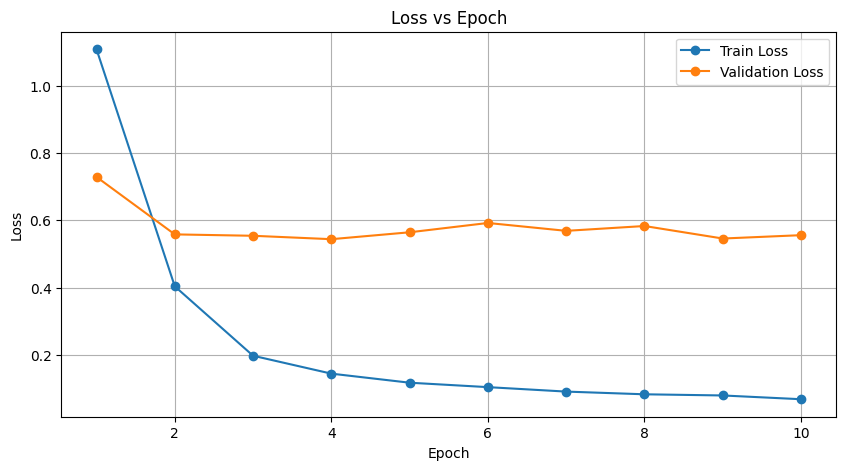

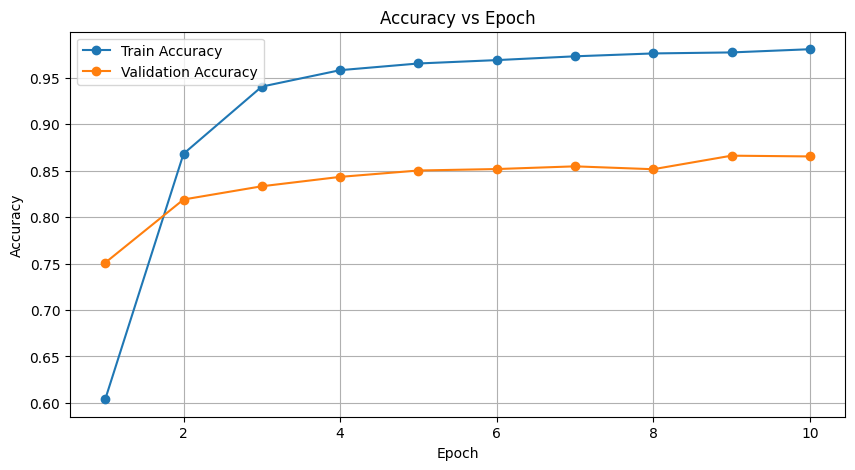

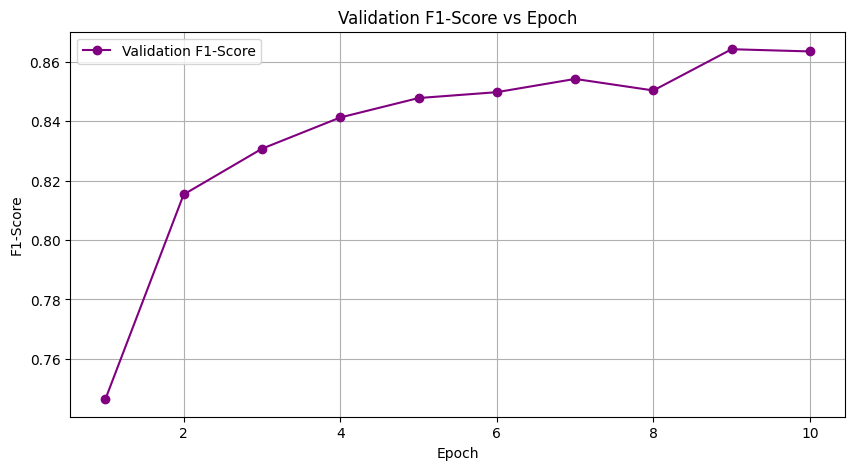

In [ ]:
import json
import matplotlib.pyplot as plt

# Load metrics
metrics_file = "/content/resnet_metrics.json"
with open(metrics_file, "r") as f:
    metrics = json.load(f)

# Extract metrics
epochs = [m['epoch'] for m in metrics]
train_losses = [m['train_loss'] for m in metrics]
val_losses = [m['val_loss'] for m in metrics]
train_accs = [m.get('train_accuracy', None) for m in metrics]  # if stored
val_accs = [m['val_accuracy'] for m in metrics]
val_f1s = [m['f1_score'] for m in metrics]

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, label="Train Loss", marker='o')
plt.plot(epochs, val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

# Plot Accuracy
plt.figure(figsize=(10, 5))
if all(train_accs):
    plt.plot(epochs, train_accs, label="Train Accuracy", marker='o')
plt.plot(epochs, val_accs, label="Validation Accuracy", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

# Plot F1-Score
plt.figure(figsize=(10, 5))
plt.plot(epochs, val_f1s, label="Validation F1-Score", marker='o', color='purple')
plt.xlabel("Epoch")
plt.ylabel("F1-Score")
plt.title("Validation F1-Score vs Epoch")
plt.legend()
plt.grid(True)
plt.show()





In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/resnet18_emotion_model.pth")

In [ ]:
!pip install mediapipe





   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 94.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 15.8 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [ ]:
# Download the MediaPipe face detection model!mkdir -p /tmp/mediapipe_models
!wget -nc https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite \
  -O /tmp/mediapipe_models/blaze_face_short_range.tflite

File ‘/tmp/mediapipe_models/blaze_face_short_range.tflite’ already there; not retrieving.


In [ ]:
import os
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
# Removed: from mediapipe.tasks.python.core import BaseOptions # This caused the ImportError


# MODEL_PATH was hardcoded, now using the global face_detector_model_path
# This path is expected to be set by a previous cell (e.g., cell bcfe3999 or e0b1f2c3)
face_detector_model_path = '/tmp/mediapipe_models/blaze_face_short_range.tflite'

base_options = python.BaseOptions(model_asset_path=face_detector_model_path)

options = vision.FaceDetectorOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    min_detection_confidence=0.5
)

detector = vision.FaceDetector.create_from_options(options)

def mask_faces_in_folder(input_root, output_root):
    os.makedirs(output_root, exist_ok=True)

    for root, _, files in os.walk(input_root):
        rel = os.path.relpath(root, input_root)
        save_dir = os.path.join(output_root, rel)
        os.makedirs(save_dir, exist_ok=True)

        for f in files:
            if not f.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            img_path = os.path.join(root, f)
            image = cv2.imread(img_path)
            if image is None:
                continue

            h, w, _ = image.shape

            mp_image = mp.Image(
                image_format=mp.ImageFormat.SRGB,
                data=cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            )

            result = detector.detect(mp_image)

            if result.detections:
                for det in result.detections:
                    bbox = det.bounding_box
                    x1 = max(0, bbox.origin_x)
                    y1 = max(0, bbox.origin_y)
                    x2 = min(w, x1 + bbox.width)
                    y2 = min(h, y1 + bbox.height)

                    # Mask face
                    image[y1:y2, x1:x2] = 0

            cv2.imwrite(os.path.join(save_dir, f), image)

# ----------------- Example Usage -----------------
train_input_folder = "/content/drive/MyDrive/CAER-S/train"
test_input_folder = "/content/drive/MyDrive/CAER-S/test"

train_output_folder = "/content/ssd_masked/train"
test_output_folder = "/content/ssd_masked/test"

mask_faces_in_folder(train_input_folder, train_output_folder)
mask_faces_in_folder(test_input_folder, test_output_folder)

In [ ]:
MODEL_PATH = "/tmp/mediapipe_models/blaze_face_short_range.tflite"
print("Model exists:", os.path.exists(MODEL_PATH))

In [ ]:
import matplotlib.pyplot as plt
import random
import os
import cv2

def display_random_masked_image(output_folder):
    all_masked_images = []
    for root, _, files in os.walk(output_folder):
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_masked_images.append(os.path.join(root, f))

    if not all_masked_images:
        print(f"No masked images found in {output_folder}")
        return

    random_image_path = random.choice(all_masked_images)
    print(f"Displaying: {random_image_path}")
    img = cv2.imread(random_image_path)
    if img is not None:
        # OpenCV reads images in BGR, matplotlib expects RGB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
        plt.title("Sample Masked Image")
        plt.axis('off')
        plt.show()
    else:
        print(f"Could not load image: {random_image_path}")

display_random_masked_image(train_output_folder)

No masked images found in /content/ssd_masked/train


In [ ]:
from torchvision import transforms

predict_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image_tensor = predict_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)
        probs = torch.softmax(outputs, dim=1)
        confidence, pred_idx = torch.max(probs, 1)

    predicted_class = class_names[pred_idx.item()]
    confidence = confidence.item()

    return predicted_class, confidence


In [ ]:
class_names = [
    "Angry", "Disgust", "Fear",
    "Happy", "Neutral", "Sad", "Surprise"
]

img_path = "/content/drive/MyDrive/CAER-S/test/Sad/2967.png"

label, confidence = predict_image(
    img_path
)

print(f"Prediction: {label} ({confidence*100:.2f}%)")


Prediction: Surprise (55.91%)


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

def show_original_and_masked(original_path, masked_path):
    orig = Image.open(original_path).convert("RGB")
    masked = Image.open(masked_path).convert("RGB")

    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(orig)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(masked)
    plt.title("Masked")
    plt.axis("off")

    plt.show()


Prediction: Sad (35.57%)


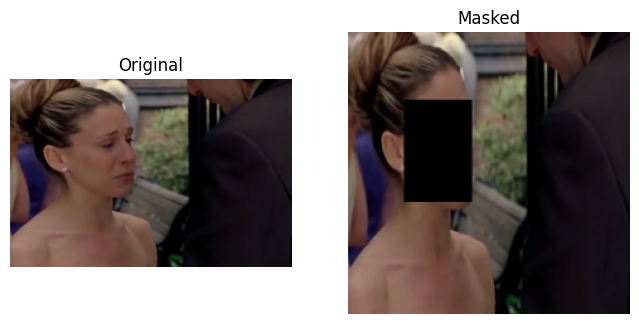

In [ ]:
orig_img = "/content/drive/MyDrive/CAER-S/test/Sad/2967.png"
masked_img = "/content/CAERS-ssd/test/Sad/2967.png"

print(f"Prediction: {label} ({confidence*100:.2f}%)")

show_original_and_masked(orig_img, masked_img)


In [ ]:
import torch.nn as nn
from torchvision import models

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


num_classes = 7  # MUST match training

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)


In [ ]:
state_dict = torch.load(
    "/content/drive/MyDrive/resnet18_emotion_model.pth",
    map_location=device
)

model.load_state_dict(state_dict)
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  